In [18]:
from langgraph.graph import StateGraph ,START,END
from pydantic import Field,BaseModel
from typing import TypedDict,Annotated
from langchain_ollama import ChatOllama
import operator

In [19]:
#defining_llm_model

model=ChatOllama(
    model='llama3.2:3b',
    temperature=0.6,
    reasoning=False
)

In [20]:
#defing_structure_of_output

class evaluation_schema(BaseModel):
    feedback : str = Field(description='correct feedback for given essay')
    score : int = Field(description='score out of 10', ge=0,le=10)

structed_model=model.with_structured_output(evaluation_schema)

In [21]:
#definig_state_of_workflow

class upsc_state(TypedDict):
    essay:str
    language_feedback:str
    analysis_feedback:str
    cot_feedback:str #criarity_of_thought
    final_feedback:str
    individual_score:Annotated[list[int],operator.add]
    avg_score:float

In [22]:
def language_evaluator(state:upsc_state):
    prompt=f"give the detailed feedback for language quality and give score out of 10 {state['essay']}"
    output=structed_model.invoke(prompt)
    return {'language_feedback':output.feedback,'individual_score':[output.score]}

In [23]:
def analysis_evaluator(state:upsc_state):
    prompt=f"give the detiled feedback for analysis quality of essay and score out of 10 {state['essay']}"
    output=structed_model.invoke(prompt)
    return {'analysis_feedback':output.feedback,'individual_score':[output.score]}

In [24]:
def  cot_evaluator(state:upsc_state):
    prompt=f'give the detiled feedback for clarity of thought and score based on that out of 10 {state["essay"]}'
    output=structed_model.invoke(prompt)
    return {"cot_feedback":output.feedback,"individual_score":[output.score]}

In [25]:
def final_evaluator(state:upsc_state):
    prompt=f"give the detailed feedback based on language  {state['language_feedback']} and analysis {state['analysis_feedback']} and clarity of thougth {state['cot_feedback']}"
    output=model.invoke(prompt)
    avg_score=sum(state['individual_score'])/len(state['individual_score'])
    return {'final_feedback':output.content,'avg_score':avg_score}

In [28]:
essays="""Artifical Inteligence is one of the most importent tecnology today.
Many peopel are using AI in there daily lifes.
It is changging the world very fastly.
AI can do many thing faster then human.
Some peopel think AI is dangrous.
Other peopel belive AI is the future.
AI help student for there homeworks.
Many student copy answer without understand it.
This is not a good habbit.
Teacher become angry becuse of this.
Hospitel are using AI for finding desease.
Sometimes AI give wrong diagonsis.
Doctor should not trust AI completly.
Companys use AI for increesing there profit.
AI save lot of times for worker.
Some worker losed there jobs becuse of automation.
This creat many social problem.
Governmant should make good ruls.
Without proper ruls AI can become harmfull.
AI also create fake imges and vedios.
This make many peopel confues.
Fake newes spread very quikly.
Peopel dont know what is true.
Privacy is another big problam.
Our data are stole by many company.
Hackers also use AI for cyber attaks.
This is very serios issue.
AI can write cod very quickly.
But many cod have buggs and erors.
Developer should alwys cheak the cod.
AI learn from datas.
If datas are bad then result also bad.
Many childrens use AI everydays.
They stop using there own brain.
School should teech how to use AI corectly.
AI can not replace human emosion.
Human have feelings but AI dont.
Future of AI is uncerten.
Many countrys invest lot of mony in AI.
Other countrys are falling behined.
This create big competation.
Scientist use AI for new medicens.
Farmer use AI for smart farmming.
Busines become more produtive with AI.
But small busines can not aford AI.
Every one should lern about AI.
AI is only a tool not a human.
If we use AI wrongly it can make many problams.
We should use AI responcibly.
Finaly AI is both usefull and dangerus.
"""

In [29]:
graph=StateGraph(upsc_state)

#definig_nodes

graph.add_node("evaluate_language", language_evaluator)
graph.add_node("evaluate_analysis", analysis_evaluator)
graph.add_node("evaluate_cot", cot_evaluator)
graph.add_node("final_evaluation", final_evaluator)

#defing_edges
graph.add_edge(START,"evaluate_language")
graph.add_edge(START,"evaluate_analysis")
graph.add_edge(START,"evaluate_cot")

graph.add_edge("evaluate_language","final_evaluation")
graph.add_edge("evaluate_analysis","final_evaluation")
graph.add_edge("evaluate_cot","final_evaluation")

graph.add_edge("final_evaluation",END)

workflow=graph.compile()

initial_state={'essay':essays}
workflow.invoke(initial_state)




{'essay': 'Artifical Inteligence is one of the most importent tecnology today.\nMany peopel are using AI in there daily lifes.\nIt is changging the world very fastly.\nAI can do many thing faster then human.\nSome peopel think AI is dangrous.\nOther peopel belive AI is the future.\nAI help student for there homeworks.\nMany student copy answer without understand it.\nThis is not a good habbit.\nTeacher become angry becuse of this.\nHospitel are using AI for finding desease.\nSometimes AI give wrong diagonsis.\nDoctor should not trust AI completly.\nCompanys use AI for increesing there profit.\nAI save lot of times for worker.\nSome worker losed there jobs becuse of automation.\nThis creat many social problem.\nGovernmant should make good ruls.\nWithout proper ruls AI can become harmfull.\nAI also create fake imges and vedios.\nThis make many peopel confues.\nFake newes spread very quikly.\nPeopel dont know what is true.\nPrivacy is another big problam.\nOur data are stole by many compa

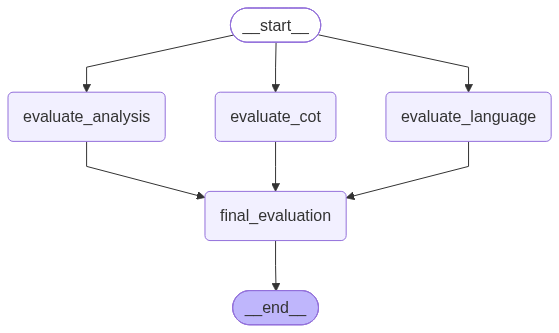

In [14]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())